## Setup

### Import Libraries

In [82]:
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.datasets import make_moons
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image
from pathlib import Path
from sklearn.datasets import make_blobs

from ipywidgets import interact, IntSlider
import copy

### Utility Functions

In [83]:
import torch.optim as optim

def do_linear_regression_interactive(model, x, y_obs, optimizer_class=optim.SGD, lr=0.1, nepochs=100):
    

    # store initial model state to reset before training
    initial_state = copy.deepcopy(model.state_dict())

    def train_and_plot(step_to_show):
        # reset model to initial state
        model.load_state_dict(copy.deepcopy(initial_state))
        optimizer = optimizer_class(model.parameters(), lr=lr)

        # train up to the selected step
        for step in range(step_to_show + 1):
            optimizer.zero_grad()
            y_pred = model(x)
            loss = (y_pred - y_obs).square().mean()
            loss.backward()
            optimizer.step()

        # plot the data and model at this step
        with torch.no_grad():
            y_pred = model(x)
            loss = (y_pred - y_obs).square().mean()

        plt.figure()
        plt.title(f"Data and Model\nstep={step_to_show}, loss={loss:.4f}")
        plt.plot(x, y_obs, "o", color="black")
        plt.plot(x, model.weight.item()*x + model.bias.item(), color="r", label="Model")
        plt.legend()
        plt.show()

    # create slider with steps of 5
    step_slider = IntSlider(min=0, max=nepochs, step=5, value=0, description='Epoch:')
    interact(train_and_plot, step_to_show=step_slider)

def do_binary_classification_interactive(model, X, labels, nepochs=40, step_size = 1, optimizer_class = torch.optim.SGD):
    """Interactive binary classification with epoch slider"""

    loss_function=nn.BCEWithLogitsLoss()

    # store initial model state to reset before training
    initial_state = copy.deepcopy(model.state_dict())

    def train_and_plot(epoch_to_show):
        # reset model to initial state
        model.load_state_dict(copy.deepcopy(initial_state))
        optimizer = optimizer_class(model.parameters(), lr=0.1)

        # Train up to the selected epoch
        for epoch in range(epoch_to_show + 1):
            optimizer.zero_grad()
            y_pred = model(X)
            loss = loss_function(y_pred.squeeze(), labels.float())
            loss.backward()
            optimizer.step()

        # Plot the result at this epoch
        with torch.no_grad():
            y_pred = model(X)
            probs = torch.sigmoid(y_pred)

        plt.figure(figsize=(6, 5))
        plt.title(f"epoch={epoch_to_show}, loss={loss.item():.4f}")
        plt.scatter(*X.T, s=20, c=(probs > 0.5).squeeze(), cmap='Set1')
        plt.show()

    # Create slider
    epoch_slider = IntSlider(min=0, max=nepochs, step=step_size, value=0, description='Epoch:')
    interact(train_and_plot, epoch_to_show=epoch_slider)

class utils:
    do_linear_regression_interactive = do_linear_regression_interactive
    do_binary_classification_interactive = do_binary_classification_interactive


## Section 1: Neural Networks can Identify Linear Relationships

| Code | Description |
| --- | --- |
| `nn.Linear(n_features_in, n_features_out)` | A single layer of nodes (neurons) that takes in `n_features_in` input features and outputs `n_features_out` features.|
| `utils.do_binary_classification(model, features, labels)` | Do binary classification. `features` is the input data and `labels` are the true class labels from the data. |
| `y_pred = model(X_input)` | Pass input `X_input` to a neuronal network `model` and assign the output to a variable `y_pred`. |
| `(y_pred-y_obs).square().mean()` | Calculate the mean squared error of the model prediction `y_pred` compared to the observed data `y_obs`. |
| `loss_function = nn.MSELoss()` | Creates a mean squared error (MSE) loss function and assigns it to a variable named `loss_function`. |
| `loss_function(y_pred, y_obs)` | Calculates the loss between the output of the network `y_pred` and the observed y-values from the data `y_obs`. |
| `loss_function(y_pred, y_obs).item()` | Extracts the loss value - i.e. the number alone as a ``float`` and not as a ``tensor``. |

Run cell below to generate linear data for binary classification

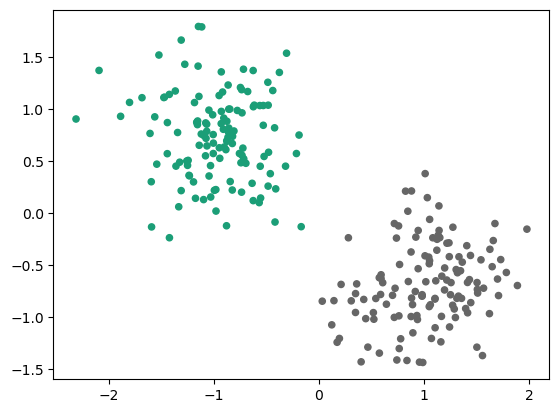

In [84]:

# generate two linearly separable clusters
features_linear, labels_linear = make_blobs(
    n_samples=256, 
    centers=[[-1, 0.7], [1, -0.7]],
    cluster_std=0.4,
    random_state=2026
)
features_linear = torch.tensor(features_linear, dtype=torch.float32)
labels_linear = torch.tensor(labels_linear, dtype=torch.long)

plt.scatter(*features_linear.T, s=20, c=labels_linear, cmap='Dark2');

**Example**: Create a linear model with 2 input features and 1 output feature. Pass this model as input to the function `utils.do_binary_classification`. Is this model able to do the classification correctly?

In [85]:
# create model
torch.manual_seed(2026)
model = nn.Linear(2,1)

utils.do_binary_classification_interactive(model, features_linear, labels_linear)

interactive(children=(IntSlider(value=0, description='Epoch:', max=40), Output()), _dom_classes=('widget-inter…

Run cell below to generate data for regression

Text(0, 0.5, 'y')

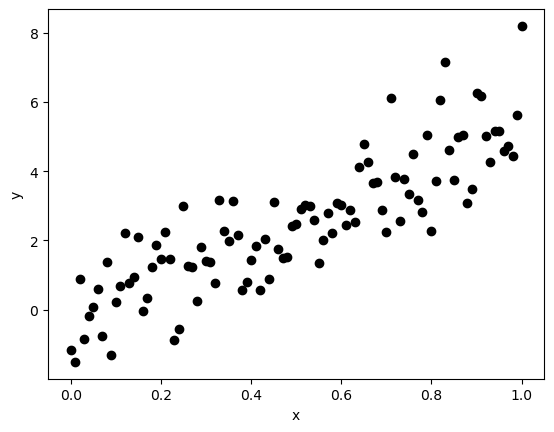

In [ ]:
torch.manual_seed(2025)

x = torch.linspace(0,1,101).unsqueeze(1)

y_obs = 5*x + torch.randn_like(x)

plt.plot(x, y_obs, 'o', color='black')
plt.xlabel("x")
plt.ylabel("y")

**Demo**: Run the cell below to see a demonstration of linear regression with PyTorch.

In [ ]:
torch.manual_seed(2025)
model = nn.Linear(1,1)

utils.do_linear_regression_interactive(model, x, y_obs)

interactive(children=(IntSlider(value=0, description='Epoch:', step=5), Output()), _dom_classes=('widget-inter…

**Example**: Create a single layer model with 2 input features and 16 output features.

In [ ]:
nn.Linear(2, 16)

Linear(in_features=2, out_features=16, bias=True)

**Exercise**: Create a single layer model with 1 input feature and 8 output features.


In [ ]:
nn.Linear(1,8)

Linear(in_features=1, out_features=8, bias=True)

**Exercise**: Create a single layer model with 20 input feature and 2 output features and assign it to a variable called `model`. Print the `model` variable.


In [ ]:
model = nn.Linear(20,8)
print(model)

Linear(in_features=20, out_features=8, bias=True)


**Exercise**: Pass the random input generated below to the model.

The output from the model should look like this:

`tensor([ 0.3933,  0.1313,  0.7289, -0.7033,  0.0142, -0.2668, -0.3853,  0.9032],
       grad_fn=<ViewBackward0>)`

In [ ]:
torch.manual_seed(2025)
input = torch.randn(20)
input

tensor([-1.1607, -1.5591,  0.7782, -0.9990,  0.4670,  1.1802,  0.3709, -2.0193,
        -1.1871, -0.2822, -0.2651,  2.7671, -1.1414,  0.3533, -0.0972, -0.1674,
         0.9320, -0.7882, -2.8070,  0.5447])

In [ ]:
model(input)

tensor([ 0.3933,  0.1313,  0.7289, -0.7033,  0.0142, -0.2668, -0.3853,  0.9032],
       grad_fn=<ViewBackward0>)

**Exercise**: Run the cell below to generate a new random input. Try to pass this input to the model. What does the error message you get say?

In [ ]:
torch.manual_seed(2025)
input = torch.randn(25)
input

tensor([-1.1607, -1.5591,  0.7782, -0.9990, -0.3729, -0.1594,  0.2836, -1.1234,
         0.9813, -0.2822, -0.2651,  2.7671,  0.8749, -0.1597, -1.5970, -0.7229,
        -0.8230, -0.7882, -2.8070,  0.5447, -1.6047,  0.2632, -1.9616, -0.9576,
        -0.5698])

In [ ]:
model(input)

RuntimeError: mat1 and mat2 shapes cannot be multiplied (1x25 and 20x8)

Presumably, you got the following error message: "RuntimeError: mat1 and mat2 shapes cannot be multiplied (1x25 and 20x8)".

You got this error because the dimensions of the input (1x25) don't match the number of input features in the model (which is 20).

This error message reveals an important fact about passing inputs through a neural network model: It's a matrix multiplication! And when you do matrix multiplication, the dimensions of the matrices (along which the multiplication is carried out) have to match. To fix the issue above, you can create a new model with 25 input features.

**Exercise**: Create a single layer with 25 input features and 2 output features and assign it to a variable called `model`. Then pass the same random input to the model as in the previous exercise. Did it run through now?

In [ ]:
model = nn.Linear(25,8)
model(input)

tensor([ 0.4385,  0.0260,  0.6803, -0.6616, -0.3066, -0.0781, -0.1993, -0.2913],
       grad_fn=<ViewBackward0>)

In the cell below, a very simple model with a single input and output feature is created. Then, the `x` data generated in the setup section is passed to it.

**Exercise**: Calculate the mean square error of the model prediction `y_pred` (compare to the observed data `y_obs`). This is the prediction loss.

**Hint**: See reference table. 

The output should look like this:

`tensor(5.5301, grad_fn=<MeanBackward0>)`

In [ ]:
torch.manual_seed(2025)

model = nn.Linear(1,1)
y_pred = model(x)

In [ ]:
(y_pred-y_obs).square().mean()

tensor(5.5301, grad_fn=<MeanBackward0>)

**Exercise**: Create a loss function using `torch`'s function `nn.MSELoss()` and assign it to a variable named `loss_function`.

In [ ]:
loss_function = nn.MSELoss()

**Exercise**: Calculate the same mean square error loss of the prediction `y_pred` using the loss function you created in the previous exercise.

In [ ]:
loss_function(y_pred, y_obs)

tensor(5.5301, grad_fn=<MseLossBackward0>)

**Exercise**: Extract the number from the loss you calculated in the previous exercise from the tensor.

**Hint**: `.item()`

In [ ]:
loss_function(y_pred, y_obs).item()

5.530094146728516

## Section 2: Activation Functions Enables Neural Networks to Capture Non-Linear Relationships in Data

Often, the relationship you want to uncover in your data isn't linear. In this section, we'll see how to make neural network models that can capture non-linear patterns in the data.

| Code | Description |
| --- | --- |
| `nn.Linear(n_features_in, n_features_out)` | A single layer of nodes (neurons) that takes in `n_features_in` input features and outputs `n_features_out` features.|
| `nn.ReLU()` | Creates a rectified linear unit (ReLU) activation function.|
| `nn.Tanh()` | Creates hyperbolic tangent activation function.|
| `nn.Sigmoid()` | Creates a sigmoid activation function.|
| `nn.Sequential(`<br>&nbsp;&nbsp;&nbsp;&nbsp;`nn.Linear(1,10),`<br>&nbsp;&nbsp;&nbsp;&nbsp;` nn.ReLU(),`<br>&nbsp;&nbsp;&nbsp;` nn.Linear(10,1)`<br>`)` | Creates a container where layers and activation functions are stacked in a sequential order. This ensures that the input is passed through the network in that order.|
| `utils.do_binary_classification(model, X, labels)` | Do binary classification. `X` is the input data and `labels` are the true class labels for the data. |
| `utils.do_binary_classification(model, X, labels, epochs=200)` | Do binary classification and set the number of epochs to 200. |

Run cell below to generate data for non-linear binary classification

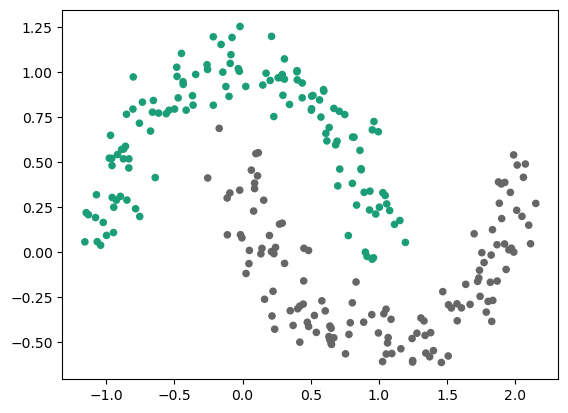

In [86]:
features_orig, labels_orig = make_moons(256, noise=0.1, random_state=42)
features = torch.tensor(features_orig, dtype=torch.float32)
labels = torch.tensor(labels_orig, dtype=torch.long)

plt.scatter(*features.T, s = 20, c = labels, cmap='Dark2');

**Example**: Create a linear model with 2 input features and 1 output feature. Pass this model as input to the function `utils.do_binary_classification`. Is this model able to do the classification correctly?

In [87]:
# create model
torch.manual_seed(2026)
model = nn.Linear(2,1)

utils.do_binary_classification_interactive(model, features, labels, optimizer_class=torch.optim.RMSprop)

interactive(children=(IntSlider(value=0, description='Epoch:', max=40), Output()), _dom_classes=('widget-inter…

**Exercise**: Use the same model to do binary classification but this time, try increasing the number of epochs (no need to go beyond 200). Is the model able to do the classification correctly now?

In [77]:
# create model
torch.manual_seed(2026)
model = nn.Linear(2,1)

utils.do_binary_classification_interactive(model, features, labels, nepochs=200, optimizer_class=torch.optim.RMSprop)

interactive(children=(IntSlider(value=0, description='Epoch:', max=200), Output()), _dom_classes=('widget-inte…

Even if the result might have improved a little bit, the linear model isn't able to do the classification correctly for all points, no matter how many epochs we train the model for. The reason is that this is a *non-linaer* problem, and a linear model will not be able to capture the non-linearities in the data. Neural networks solves this by adding an *activation function* to the nodes.

**Demo**: Create a model composed of two layers with a *rectified linear* unit between them. The first layer has two input features and one 16 output features, the last layer has 16 input features and 1 output feature. Pass the model to the utility function `utils.do_binary_classification` together with the features and the labels. Is the model able to correctly classify the points now?

In [91]:
torch.manual_seed(2026)
# create model
model = nn.Sequential(
    nn.Linear(2,16),
    nn.ReLU(),
    nn.Linear(16,1)
)

utils.do_binary_classification_interactive(model, features, labels, nepochs = 200, optimizer_class=torch.optim.RMSprop)

interactive(children=(IntSlider(value=0, description='Epoch:', max=200), Output()), _dom_classes=('widget-inte…

There are different kinds of activation functions. Let's take a look at what some of the most common ones do to their input.

**Example**: Pass the tensor `x` provided below to a rectified linear unit (ReLU) activation function and assign the output to a variable named `out`. Then, run the cell with the code that plots the output against `x`. The plot shows to form of the ReLU function.

In [ ]:
x = torch.linspace(-5,5,100)

In [ ]:
out = nn.ReLU()(x)

Text(0.5, 1.0, ' ReLU\nActivation Function')

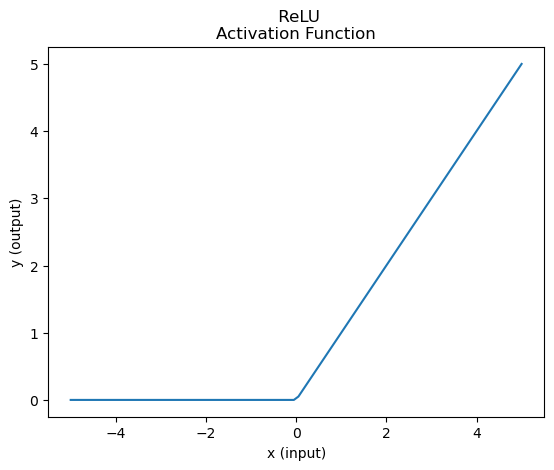

In [ ]:
plt.plot(x,out)
plt.xlabel('x (input)')
plt.ylabel('y (output)')
plt.title(' ReLU\nActivation Function')

**Exercise**: Pass the tensor `x` provided below to a rectified linear unit (ReLU) activation function and assign the output to a variable named `out`. Then, run the cell with the code that plots the output against `x`. The plot shows to form of the hyperbolic tangent function.

In [ ]:
x = torch.linspace(-5,5,100)

In [ ]:
out = nn.Tanh()(x)

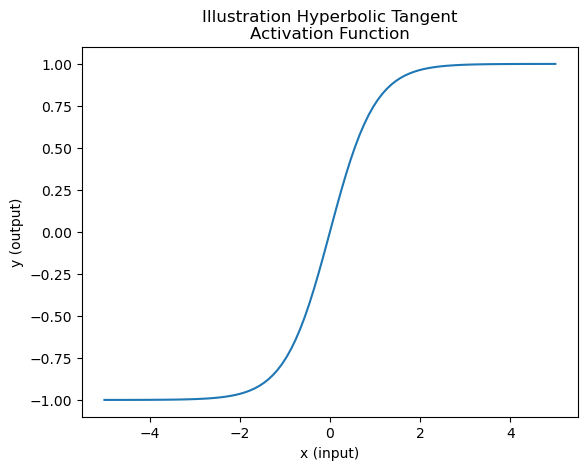

In [ ]:
plt.plot(x, out)
plt.xlabel('x (input)')
plt.ylabel('y (output)')
plt.title('Illustration Hyperbolic Tangent\nActivation Function');

**Exercise**: Pass the tensor `x` provided below to a hyperbolic tangent (tanh) activation function and assign the output to a variable named `out`. Then, run the cell with the code that plots this output against `x`. What effect does this activation function have on the input?

**Hint**: Look at the maximum and minimum value on the y-axis of the output relative to the input.

In [ ]:
torch.manual_seed(2025)
x = torch.randn(20)
x

tensor([-1.1607, -1.5591,  0.7782, -0.9990,  0.4670,  1.1802,  0.3709, -2.0193,
        -1.1871, -0.2822, -0.2651,  2.7671, -1.1414,  0.3533, -0.0972, -0.1674,
         0.9320, -0.7882, -2.8070,  0.5447])

In [ ]:
out = nn.Tanh()(x)

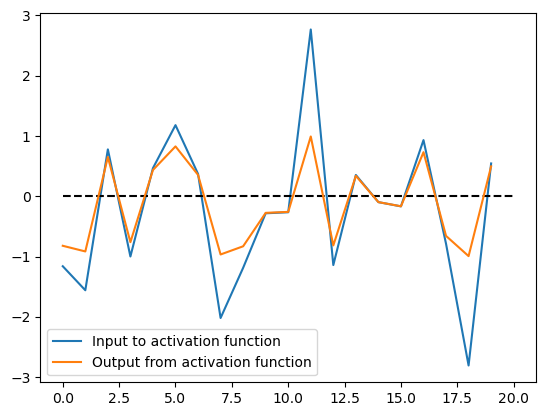

In [ ]:
plt.plot(x, label = 'Input to activation function')
plt.hlines(xmin=0, xmax=len(x), y=0, ls='--', colors='k')
plt.plot(out, label ='Output from activation function')
plt.legend();

**Exercise**: Pass the tensor `x` provided below to a sigmoid activation function and assign the output to a variable named `out`. Then, run the cell with the code that plots the output against `x`. The plot shows to form of the sigmoid function.

In [ ]:
x = torch.linspace(-5,5,100)

In [ ]:
out = nn.Sigmoid()(x)

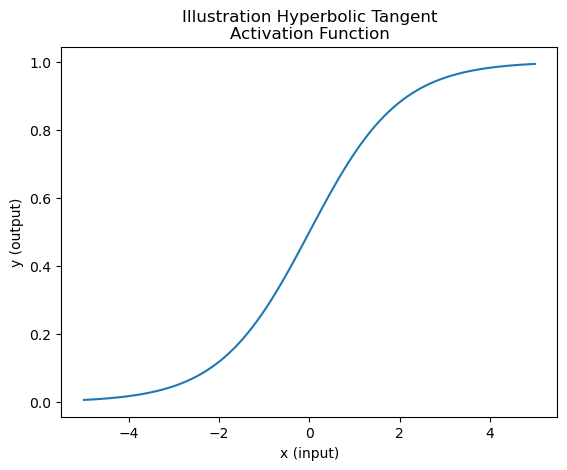

In [ ]:
plt.plot(x, out)
plt.xlabel('x (input)')
plt.ylabel('y (output)')
plt.title('Illustration Hyperbolic Tangent\nActivation Function');

**Exercise**: Pass the tensor `x` provided below to a hyperbolic tangent (tanh) activation function and assign the output to a variable named `out`. Then, run the cell with the code that plots this output against `x`. What effect does this activation function have on the input?

**Hint**: Look at the maximum and minimum value of the output on the y-axis.

In [ ]:
torch.manual_seed(2025)
x = torch.randn(20)
x

tensor([-1.1607, -1.5591,  0.7782, -0.9990,  0.4670,  1.1802,  0.3709, -2.0193,
        -1.1871, -0.2822, -0.2651,  2.7671, -1.1414,  0.3533, -0.0972, -0.1674,
         0.9320, -0.7882, -2.8070,  0.5447])

In [ ]:
out = nn.Sigmoid()(x)

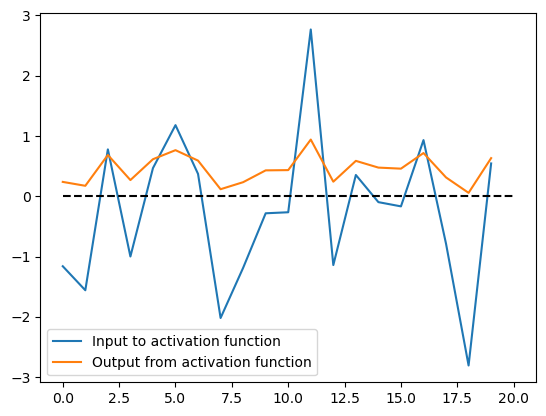

In [ ]:
plt.plot(x, label = 'Input to activation function')
plt.hlines(xmin=0, xmax=len(x), y=0, ls='--', colors='k')
plt.plot(out, label ='Output from activation function')
plt.legend();

The hyperbolic tangent activation function was popular in early neural networks because it led to to faster convergence during training. However, it was later shown that the rectified linear unit (ReLU) often produced better results, and since then, ReLU has been the most commonly used activation function in neural networks. Sigmoid activation functions are often used to convert the output at the end of a network to probabilities between 0 and 1, which is particularly relevant for binary classification problems.

## Section 3: The Loss Function for Classification

| Code | Description |
| --- | --- |
| `nn.CrossEntropyLoss()` | Creates a cross-entropy loss function for multiclass classification problems.|
| `nn.BCELogitsWithLoss()` | Creates a cross-entropy loss function for binary classification problems.|


## Section 4: Optimizers


| Code | Description |
| --- | --- |
| `torch.optim.SGD(model.parameters())` | Creates a gradient descent (GD) optimizer. |
| `torch.optim.SGD(model.parameters(), lr=0.01, momentum = 0.99)` | Creates a gradient descent (GD) optimizer with a learning rate `lr` of 0.01 (the default value is 0.001) and ``momentum`` of 0.99 (the default value is 0.9). |
| `torch.optim.RMSprop(model.parameters())` | Creates an adaptive gradient descent optimizer.|
| `torch.optim.Adam(model.parameters())` | Creates an adaptive moment optimizer .|
| `utils.do_binary_classification(X, labels)` | Do multiclass classification. `X` is the input data and `labels` are the true class labels for the data. |
| `utils.do_binary_classification(X, labels, loss_function=nn.CrossEntropyLoss())` | Do multiclass classification and set the loss function to torch's cross entropy loss. |
| `utils.do_binary_classification(X, labels, optimizer=torch.optim.SGD)` | Do multiclass classification with gradient descent as the optimization algorithm. |